**Libraries**

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

**Load cleaned dataset**

In [2]:
df=pd.read_csv('/content/encoded_factory_data.csv')
df.head()

,UDI,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,H,L
0,1,M14860,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,False
1,2,L47181,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,False,True
2,3,L47182,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,False,True
3,4,L47183,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,False,True
4,5,L47184,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,False,True


**Drop unnecessary columns**

In [4]:
df=df.drop(['UDI','Product ID'],axis='columns')
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,H,L
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,False
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,False,True
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,False,True
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,False,True
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,False,True


**Create Features**

In [5]:
X=df.drop([
    'Process temperature [K]',
    'Machine failure'
], axis='columns')

**Create Target**

In [6]:
y=df['Process temperature [K]']

**Train Test split**

In [8]:
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Verify Split**

In [9]:
print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


**Model**

In [11]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

**Predict**

In [12]:
predictions=model.predict(X_test)

**Error**

In [17]:
mse=mean_squared_error(y_test,predictions)
mse

0.5260419864244282

**Visualise Results**

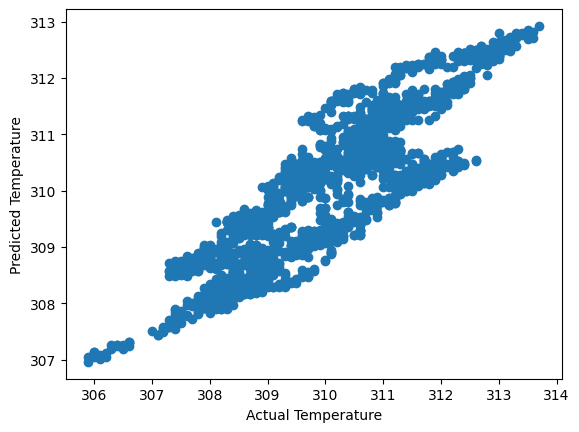

In [19]:
plt.scatter(y_test,predictions)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.show()

In [20]:
X.columns

Index(['Air temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'H', 'L'],
      dtype='object')